In [51]:
import keras
from keras import layers

# Tamaño de la representación de codificación 
encoding_dim = 32 # factor de compresión 24.5, asumiendo la entrada de 784 dimensiones

# Input de la imagen
input_img = keras.Input(shape=(784,))

# "encoded" es la representación codificada de la entrada
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

# "decoded" es la pérdida de la entrada reconstruida
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# Este modelo mapea una imagen de entrada a su reconstrucción
autoencoder = keras.Model(input_img, decoded)


In [52]:
# Este modelo mapea una imagen de entrada a su representación codificada
encoder = keras.Model(input_img, encoded)

In [53]:
# Este modelo mapea una representación codificada a su reconstrucción
encoded_input = keras.Input(shape=(encoding_dim,))

# Recupera la última capa del modelo autoencoder
decoder_layer = autoencoder.layers[-1]

# Crea el modelo decodificador
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))




In [54]:
# Compila el modelo autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

(342, 548, 3)
(28, 28, 1)


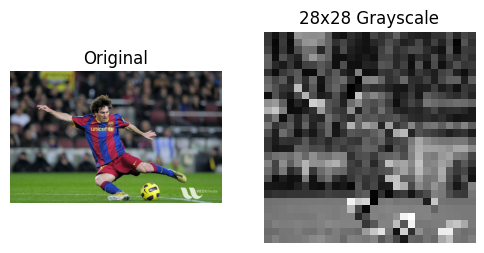

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# Carga de la imagen de messi en la carpeta raiz
url = "C:\\Proyectos\\VIU\\VIU_Misc\\Aprendizaje_No_Supervisado\\messi5.jpg"

raw_messi = keras.preprocessing.image.load_img(url)
raw_messi = keras.preprocessing.image.img_to_array(raw_messi)
print(raw_messi.shape)

messi = keras.preprocessing.image.load_img(url, target_size=(28, 28), color_mode='grayscale')
messi = keras.preprocessing.image.img_to_array(messi)
print(messi.shape)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(raw_messi.astype(np.uint8))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("28x28 Grayscale")
plt.imshow(messi.squeeze(), cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
x_train = np.array([messi])
x_test = np.array([messi])  
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(1, 784)
(1, 784)


In [74]:

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.5504

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.5504 - val_loss: 0.5504
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.5504 - val_loss: 0.5504


In [75]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [76]:
encoded_imgs.shape

(1, 32)

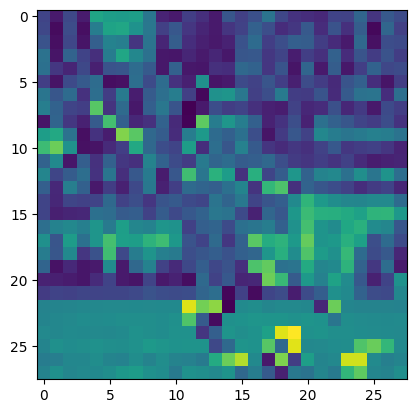

(<matplotlib.image.AxesImage at 0x2ce245e1310>, None)

In [77]:
plt.imshow(x_test[0].reshape(28, 28)), plt.show()

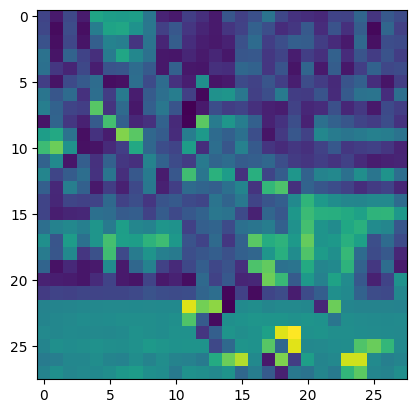

(<matplotlib.image.AxesImage at 0x2ce226d9590>, None)

In [78]:
plt.imshow(decoded_imgs[0].reshape(28, 28)), plt.show()

In [79]:
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

In [80]:
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,
                epochs=100,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.6928 - val_loss: 0.6909
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.6909 - val_loss: 0.6873
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.6873 - val_loss: 0.6819
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.6819 - val_loss: 0.6745
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - loss: 0.6745 - val_loss: 0.6653
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - loss: 0.6653 - val_loss: 0.6541
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 0.6541 - val_loss: 0.6414
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 0.6414 - val_loss: 0.6281
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.6281 - val_loss: 0.6156
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.6156 - val_loss: 0.6054
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.6054 - val_loss: 0.5983
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 0.5983

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


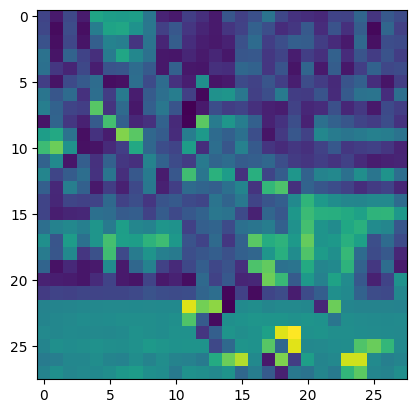

(<matplotlib.image.AxesImage at 0x2ce21b847d0>, None)

In [81]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

plt.imshow(decoded_imgs[0].reshape(28, 28)), plt.show()